# Score vs Performance-Rating MC Calibration Backtest

Compares two Monte Carlo ranking signals over the 2025-11-04 -> present window:

- **`score`**  : `score * 10000 + tiebreak`  (current production default)
- **`perf`**   : `performance_rating` (aroc_1-based Elo estimate)

Both share the same attendance model (EWMA over the 2025-09-02+ single-session era)
and the same simulation kernel. The only difference is the skill signal drawn per
player from their historical distribution.

Predictions and outcomes live in the `backtest` table populated by
`scripts/run_backtest.py`. Row = (tourn_date, model, username).

In [1]:
import sys, sqlite3
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import DB_PATH

pd.set_option('display.max_rows', 200)
plt.rcParams.update({'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False})

N_VALUES = [1, 3, 5, 8, 10]

In [2]:
with sqlite3.connect(DB_PATH) as conn:
    df = pd.read_sql_query('SELECT * FROM backtest', conn, parse_dates=['tourn_date'])

# Marginal P(top-N) = p_participate * P(top-N | play)
for k in N_VALUES:
    df[f'P_top{k}'] = df['p_participate'] * df[f'P_top{k}_given_play']

# Actual top-N outcome (1 if player played and finished with rank <= k)
for k in N_VALUES:
    df[f'in_top{k}'] = ((df['played'] == 1) & (df['actual_rank'] <= k)).astype(int)

print(f"{len(df):,} rows | {df['tourn_date'].nunique()} tournaments | models={df['model'].unique().tolist()}")
df.groupby('model').size().rename('rows').to_frame()

524,078 rows | 45 tournaments | models=['score', 'perf']


,rows
model,
perf,216011
score,308067


## Pool sizes per tournament

The perf-rating pool is smaller than the score pool because rows lacking `aroc_1`
(mostly pre-2022) are dropped. Player-tournament pairs where the two models
disagree on eligibility distort a direct comparison; we handle this two ways:

1. **Own-pool view**   -- calibration on each model's own player set (natural but the sets differ).
2. **Intersection view** -- restrict to players present in *both* pools each week.

model    perf   score
count    45.0    45.0
mean   4800.0  6846.0
std     130.0   131.0
min    4602.0  6646.0
25%    4697.0  6740.0
50%    4785.0  6833.0
75%    4896.0  6943.0
max    5040.0  7085.0


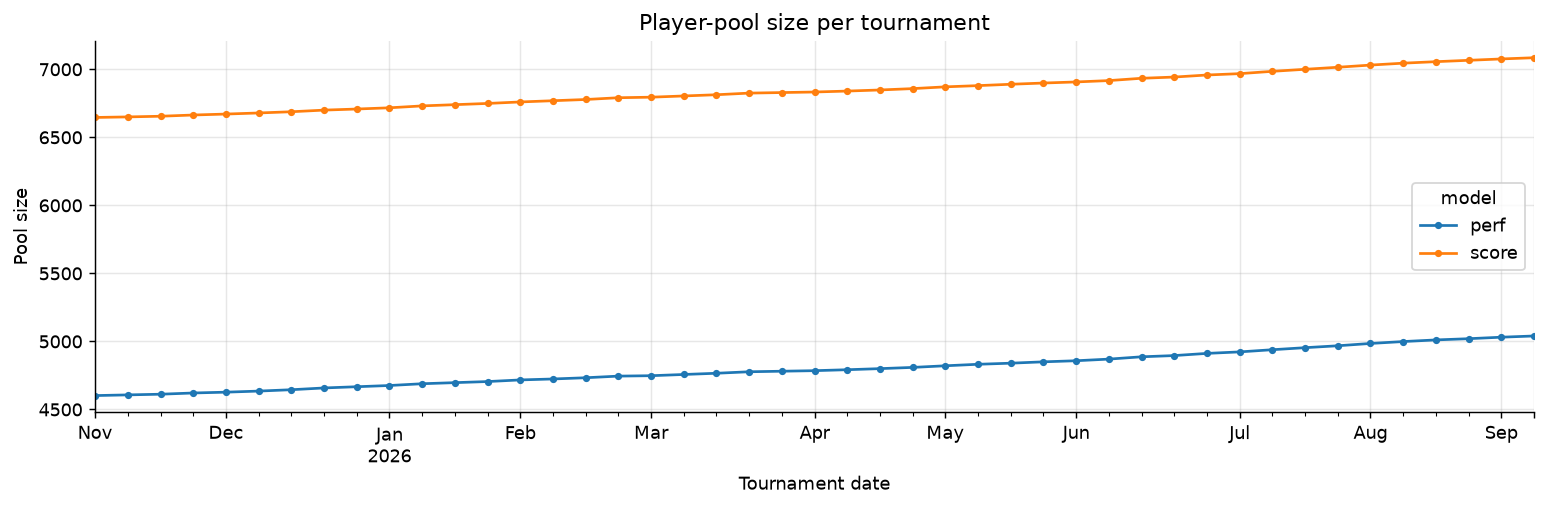

In [3]:
pool_sizes = df.groupby(['tourn_date', 'model']).size().unstack('model')
print(pool_sizes.describe().round(0))

fig, ax = plt.subplots(figsize=(12, 4))
pool_sizes.plot(ax=ax, marker='o', ms=3)
ax.set_title('Player-pool size per tournament')
ax.set_ylabel('Pool size')
ax.set_xlabel('Tournament date')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
# Build 'intersection' view: keep only (tourn_date, username) pairs present in BOTH models
counts = df.groupby(['tourn_date', 'username'])['model'].nunique()
keep = counts[counts == 2].index
df_isect = df.set_index(['tourn_date', 'username']).loc[keep].reset_index()
print(f"Intersection rows: {len(df_isect):,}  ({len(df_isect)//2:,} per model)")

Intersection rows: 432,022  (216,011 per model)


## Attendance calibration

`played` is a Bernoulli outcome. We compare Brier score and log-loss.
Both models use identical `p_participate`, so any difference here reflects
only the different eligibility filter (i.e., whether the perf pool's smaller
subset happens to attend at systematically different rates).

In [5]:
def brier(p, y):
    return float(np.mean((p - y) ** 2))

def log_loss(p, y, eps=1e-9):
    p = np.clip(p, eps, 1 - eps)
    return float(-np.mean(y * np.log(p) + (1 - y) * np.log(1 - p)))

def rows_metrics(sub, col_p, col_y):
    return {
        'n': len(sub),
        'base_rate': float(sub[col_y].mean()),
        'mean_pred': float(sub[col_p].mean()),
        'brier': brier(sub[col_p].to_numpy(), sub[col_y].to_numpy()),
        'log_loss': log_loss(sub[col_p].to_numpy(), sub[col_y].to_numpy()),
    }

rows = []
for src, tag in [(df, 'own_pool'), (df_isect, 'intersect')]:
    for m in ('score', 'perf'):
        sub = src[src['model'] == m]
        rows.append({'view': tag, 'model': m, **rows_metrics(sub, 'p_participate', 'played')})
att_metrics = pd.DataFrame(rows)
att_metrics

,view,model,n,base_rate,mean_pred,brier,log_loss
0,own_pool,score,308067,0.050866,0.049596,0.030725,0.109144
1,own_pool,perf,216011,0.070071,0.066240,0.042009,0.146608
2,intersect,score,216011,0.070071,0.066240,0.042009,0.146608
3,intersect,perf,216011,0.070071,0.066240,0.042009,0.146608


## Top-N calibration (marginal + conditional)

For each top-N cutoff we score:

- `P_top{N}` (marginal) vs `in_top{N}` (played & rank <= N)  -- overall calibration.
- `P_top{N}_given_play` vs `in_top{N}` restricted to `played == 1` -- skill-model calibration.

Brier + log-loss per model per N, computed on the intersection view.

In [6]:
def score_all(src, view_tag):
    rows = []
    for k in N_VALUES:
        for m in ('score', 'perf'):
            sub = src[src['model'] == m]
            rows.append({
                'view': view_tag, 'metric': 'marginal', 'N': k, 'model': m,
                **rows_metrics(sub, f'P_top{k}', f'in_top{k}'),
            })
            play = sub[sub['played'] == 1]
            rows.append({
                'view': view_tag, 'metric': 'given_play', 'N': k, 'model': m,
                **rows_metrics(play, f'P_top{k}_given_play', f'in_top{k}'),
            })
    return pd.DataFrame(rows)

metrics = pd.concat(
    [score_all(df, 'own_pool'), score_all(df_isect, 'intersect')],
    ignore_index=True,
)
metrics.round(6)

,view,metric,N,model,n,base_rate,mean_pred,brier,log_loss
0,own_pool,marginal,1,score,308067,0.000146,0.000146,0.000141,0.000728
1,own_pool,given_play,1,score,15670,0.002872,0.003323,0.002702,0.012350
2,own_pool,marginal,1,perf,216011,0.000208,0.000208,0.000202,0.001131
3,own_pool,given_play,1,perf,15136,0.002973,0.003446,0.002850,0.014135
4,own_pool,marginal,3,score,308067,0.000438,0.000438,0.000391,0.001686
5,own_pool,given_play,3,score,15670,0.008615,0.010081,0.007235,0.027699
6,own_pool,marginal,3,perf,216011,0.000620,0.000625,0.000557,0.002609
7,own_pool,given_play,3,perf,15136,0.008853,0.010418,0.007619,0.032288
8,own_pool,marginal,5,score,308067,0.000730,0.000730,0.000639,0.002646
9,own_pool,given_play,5,score,15670,0.014359,0.016858,0.011689,0.042705


Brier (intersection view, lower is better):
model              perf     score  delta_perf_minus_score
metric     N                                             
given_play 1   0.002850  0.002797                0.000053
           3   0.007619  0.007417                0.000202
           5   0.012316  0.011853                0.000463
           8   0.018019  0.017309                0.000711
           10  0.021657  0.020968                0.000689
marginal   1   0.000202  0.000200                0.000002
           3   0.000557  0.000553                0.000003
           5   0.000905  0.000893                0.000011
           8   0.001369  0.001350                0.000019
           10  0.001679  0.001661                0.000018


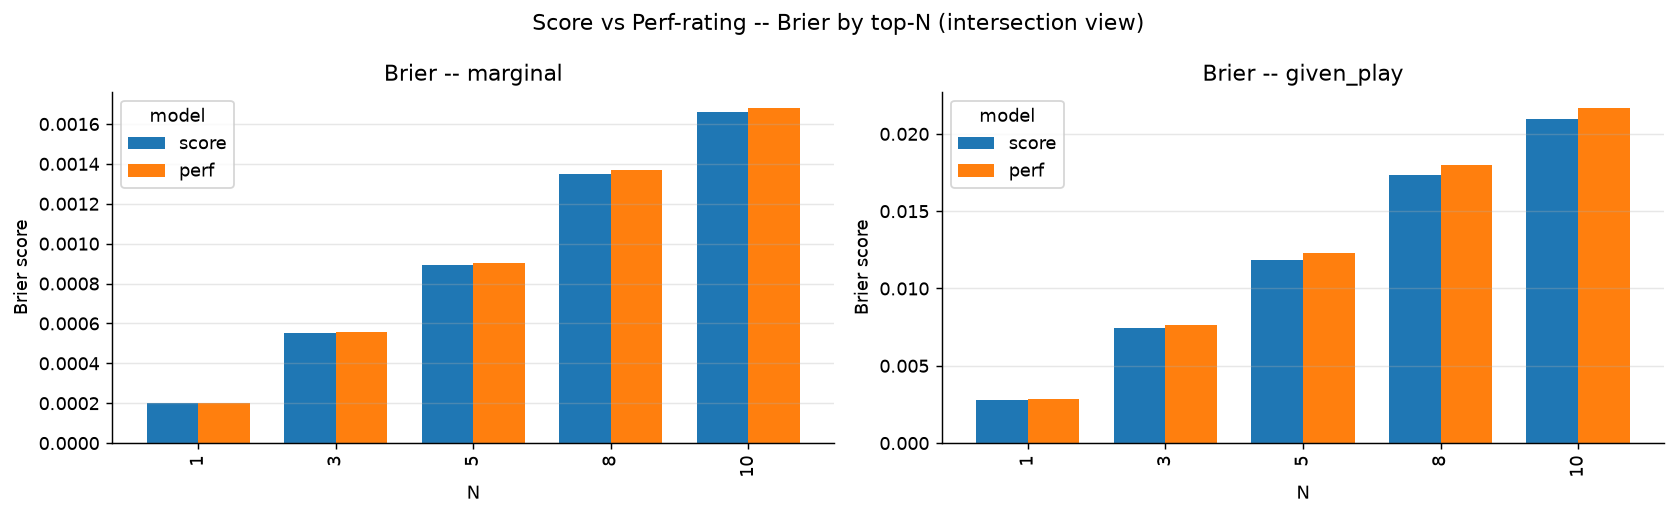

In [7]:
wide = (metrics[metrics['view'] == 'intersect']
        .pivot_table(index=['metric', 'N'], columns='model', values='brier'))
wide['delta_perf_minus_score'] = wide['perf'] - wide['score']
print('Brier (intersection view, lower is better):')
print(wide.round(6))

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)
for ax, metric in zip(axes, ('marginal', 'given_play')):
    sub = wide.xs(metric, level='metric')[['score', 'perf']]
    sub.plot.bar(ax=ax, width=0.75)
    ax.set_title(f'Brier -- {metric}')
    ax.set_xlabel('N')
    ax.set_ylabel('Brier score')
    ax.grid(alpha=0.3, axis='y')
plt.suptitle('Score vs Perf-rating -- Brier by top-N (intersection view)')
plt.tight_layout()
plt.show()

## Calibration curves (reliability diagrams)

Bin predictions by probability; plot mean-predicted vs empirical-frequency.
A well-calibrated model sits on the diagonal.

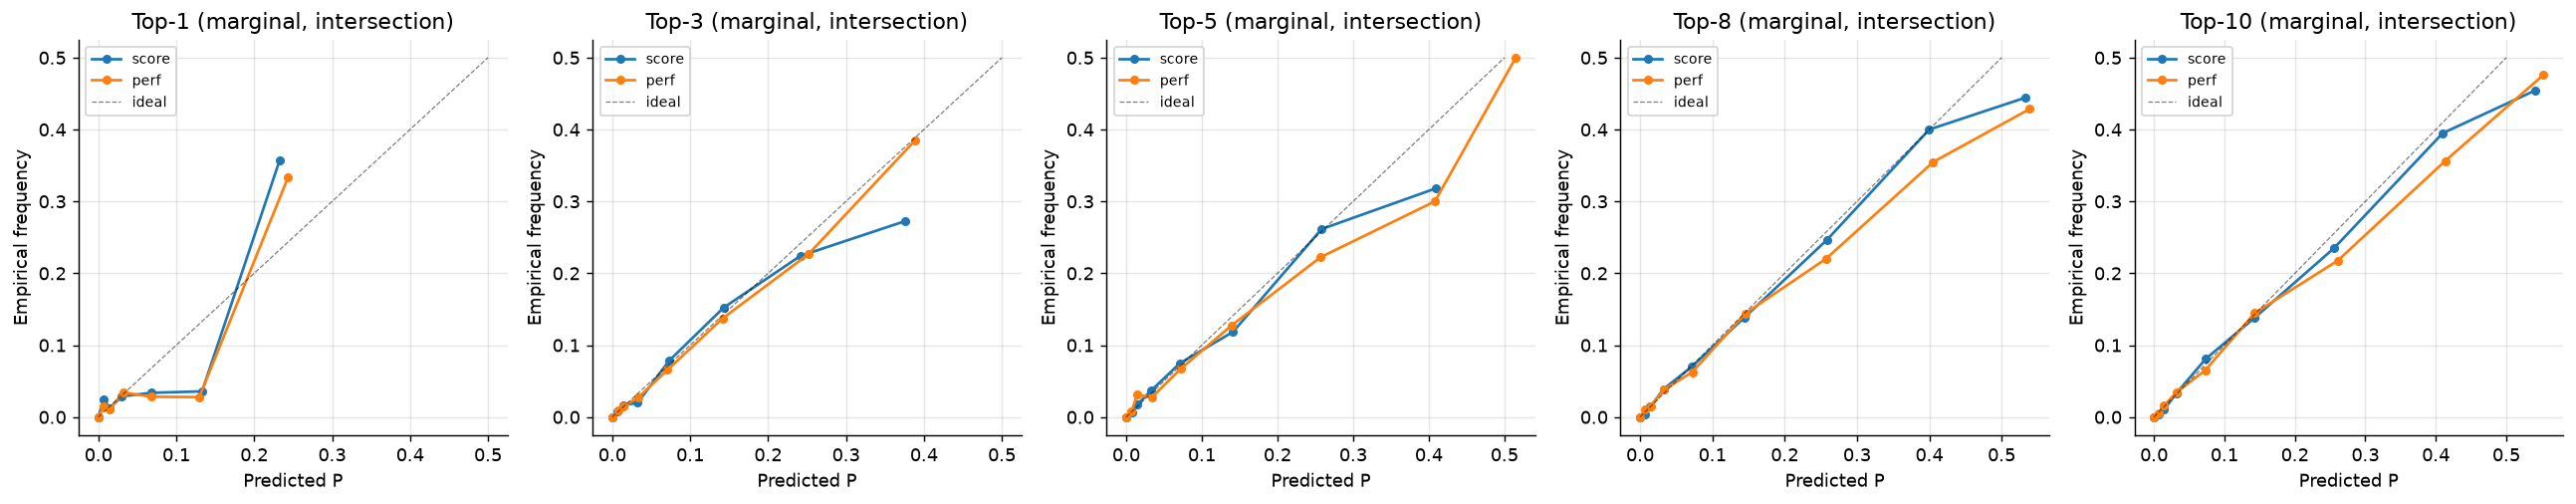

In [8]:
def cal_curve(p, y, bins=None):
    if bins is None:
        bins = [0, 0.005, 0.01, 0.02, 0.05, 0.10, 0.20, 0.35, 0.50, 0.70, 1.0]
    b = np.digitize(p, bins) - 1
    b = np.clip(b, 0, len(bins) - 2)
    out = []
    for i in range(len(bins) - 1):
        m = b == i
        if m.sum() > 0:
            out.append({
                'bin_lo': bins[i], 'bin_hi': bins[i+1],
                'n': int(m.sum()),
                'mean_pred': float(p[m].mean()),
                'emp_rate': float(y[m].mean()),
            })
    return pd.DataFrame(out)

fig, axes = plt.subplots(1, len(N_VALUES), figsize=(4 * len(N_VALUES), 4), sharex=False, sharey=False)
for ax, k in zip(axes, N_VALUES):
    for m, color in zip(('score', 'perf'), ('C0', 'C1')):
        sub = df_isect[df_isect['model'] == m]
        p = sub[f'P_top{k}'].to_numpy()
        y = sub[f'in_top{k}'].to_numpy()
        c = cal_curve(p, y)
        ax.plot(c['mean_pred'], c['emp_rate'], 'o-', ms=4, label=m, color=color)
    ax.plot([0, 0.5], [0, 0.5], 'k--', lw=0.7, alpha=0.5, label='ideal')
    ax.set_title(f'Top-{k} (marginal, intersection)')
    ax.set_xlabel('Predicted P')
    ax.set_ylabel('Empirical frequency')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Rank-metric: how well does each model rank players?

Even if raw probabilities are miscalibrated, one model can still order
players better than the other. For each tournament, ROC-AUC on
`in_topN` gives a pure ranking measure.

Mean AUC (higher is better):
         mean             std         count      
model    perf   score    perf   score  perf score
N                                                
1      0.9850  0.9960  0.0754  0.0050    45    45
3      0.9818  0.9927  0.0496  0.0261    45    45
5      0.9866  0.9910  0.0301  0.0226    45    45
8      0.9880  0.9879  0.0254  0.0263    45    45
10     0.9864  0.9871  0.0228  0.0253    45    45


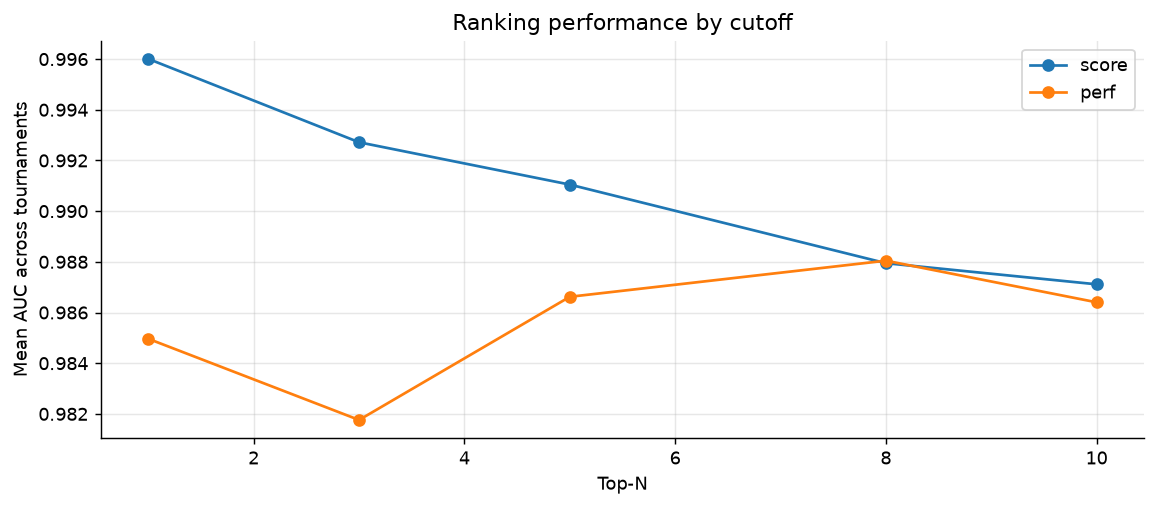

In [9]:
from scipy.stats import rankdata

def _auc(p, y):
    """Mann-Whitney U form of ROC-AUC, tie-safe via fractional ranks."""
    y = np.asarray(y); p = np.asarray(p)
    pos = int(y.sum()); neg = len(y) - pos
    if pos == 0 or neg == 0:
        return np.nan
    r = rankdata(p)  # ascending; ties get mean rank
    r_pos = r[y == 1].sum()
    return float((r_pos - pos * (pos + 1) / 2) / (pos * neg))

rows = []
for (date, m), sub in df_isect.groupby(['tourn_date', 'model']):
    for k in N_VALUES:
        rows.append({
            'tourn_date': date, 'model': m, 'N': k,
            'auc': _auc(sub[f'P_top{k}'].to_numpy(), sub[f'in_top{k}'].to_numpy()),
        })
auc_df = pd.DataFrame(rows)
auc_summary = auc_df.groupby(['N', 'model'])['auc'].agg(['mean', 'std', 'count']).unstack('model')
print('Mean AUC (higher is better):')
print(auc_summary.round(4))

fig, ax = plt.subplots(figsize=(9, 4))
for m, color in zip(('score', 'perf'), ('C0', 'C1')):
    sub = auc_df[auc_df['model'] == m].groupby('N')['auc'].mean()
    ax.plot(sub.index, sub.values, 'o-', label=m, color=color)
ax.set_xlabel('Top-N')
ax.set_ylabel('Mean AUC across tournaments')
ax.set_title('Ranking performance by cutoff')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Summary: which model wins on which metric?

Intersection view. Lower Brier / higher AUC wins.

In [10]:
brier_wide = (metrics[metrics['view'] == 'intersect']
              .pivot_table(index=['metric', 'N'], columns='model', values='brier'))
brier_wide['winner_brier'] = np.where(brier_wide['score'] < brier_wide['perf'], 'score', 'perf')

auc_wide = auc_df.groupby(['N', 'model'])['auc'].mean().unstack('model')
auc_wide['winner_auc'] = np.where(auc_wide['score'] > auc_wide['perf'], 'score', 'perf')

print('=== Brier winners (marginal + given_play) ===')
print(brier_wide.round(6))
print()
print('=== AUC winners (marginal, per N) ===')
print(auc_wide.round(4))

=== Brier winners (marginal + given_play) ===
model              perf     score winner_brier
metric     N                                  
given_play 1   0.002850  0.002797        score
           3   0.007619  0.007417        score
           5   0.012316  0.011853        score
           8   0.018019  0.017309        score
           10  0.021657  0.020968        score
marginal   1   0.000202  0.000200        score
           3   0.000557  0.000553        score
           5   0.000905  0.000893        score
           8   0.001369  0.001350        score
           10  0.001679  0.001661        score

=== AUC winners (marginal, per N) ===
model    perf   score winner_auc
N                               
1      0.9850  0.9960      score
3      0.9818  0.9927      score
5      0.9866  0.9910      score
8      0.9880  0.9879       perf
10     0.9864  0.9871      score
